# 📊 Projeto de Classificação: Predição de Risco de Diabetes

---

#### Disciplina: Inteligência Artificial: Model LifeCycle
#### Professor: Diego da Silva Rodrigues
#### Aluno: André Luis Becker

---

### 1. Objetivo e Contextualização

Este projeto tem como objetivo desenvolver um modelo preditivo supervisionado
para identificar o risco de diabetes em indivíduos com base em dados
populacionais. Utiliza-se como base o conjunto de dados do CDC (EUA),
disponibilizado publicamente, contendo informações clínicas e comportamentais.

---

## 🧠 Questão 1 – Estruturação conceitual do problema de modelagem

Trata-se de um problema de **classificação supervisionada**, pois a base possui uma variável-alvo binária (`Diabetes_binary`) indicando presença ou ausência de diabetes. As variáveis explicativas incluem IMC, dieta, exercício, entre outras.

✅ Conceitos de ML:
- Justificativa do uso de ML supervisionado ✔️
- Diferenciação com não supervisionado ✔️
- Bibliotecas identificadas e explicadas ✔️
- Dois desafios relacionados aos dados ✔️

### Desafios:
- **Normalização**: o algoritmo KNN depende de distâncias, exigindo escalonamento.
- **Desequilíbrio de classes**: pode enviesar o modelo se não tratado.

### Bibliotecas utilizadas:
- `scikit-learn`: modelos, métricas e validação
- `pandas`/`numpy`: manipulação de dados
- `matplotlib`/`seaborn`: visualizações
- `ucimlrepo`: acesso direto ao dataset oficial


In [11]:
# Instalação do pacote necessário em modo silencioso "--quiet":

!pip install ucimlrepo --quiet

In [12]:
# Importando as bibliotecas necessárias:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, classification_report
from ucimlrepo import fetch_ucirepo
import warnings
warnings.filterwarnings("ignore")

## 📥 Questão 2 – Implementação com KNN
✅ Questão 2A - Carregamento e Visualização Inicial dos Dados:
- Carregamento da base ✔️
- Identificação do target e features ✔️

R.:
Realizei a junção das variáveis explicativas com a variável-alvo para facilitar o
tratamento posterior. Renomeei a coluna final para "Diabetes" para melhorar a legibilidade.

In [13]:
# Carregamento e estruturação dos dados:
cdc_data = fetch_ucirepo(id=891)
X = cdc_data.data.features
y = cdc_data.data.targets

# Análise Inicial:
print(f"Número de amostras: {X.shape[0]}")
print(f"Número de features: {X.shape[1]}")
print(f"Variável-alvo:")
print(y.value_counts(normalize=True))

# Combinando `X` e `y` e renomeando para facilitar o processamento:
df = pd.concat([X, y], axis=1)
df.rename(columns={df.columns[-1]: "Diabetes"}, inplace=True)
print(f'\nDados carregados com sucesso: {df.shape}')
df.head()

Número de amostras: 253680
Número de features: 21
Variável-alvo:
Diabetes_binary
0                  0.860667
1                  0.139333
Name: proportion, dtype: float64

Dados carregados com sucesso: (253680, 22)


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0


✅ Questão 2B - Separação dos Dados:
- Split treino/teste com `stratify` + justificativa ✔️

R.:
Usei `stratify=y` para preservar a distribuição de classes no treino e no teste.
Isso é essencial, pois há um desequilíbrio entre as classes e manter a proporção ajuda a treinar modelos mais justos.

In [14]:
# Separação treino/teste:
X = df.drop("Diabetes", axis=1)
y = df["Diabetes"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

✅ Questão 2C - Normalização dos dados explicada e aplicada:
- Aplica e justifica a normalização ✔️

In [15]:
# Normalização:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

✅ Questão 2D - Parâmetro K:
- Análise da variação do parâmetro K (gráfico + decisão) ✔️

R.:
Testei diferentes valores de K com validação cruzada (5-fold). Observei que valores entre 5 e 10 tendem a ser mais estáveis.
Escolhi o K que apresentou melhor acurácia média.

## 🧪 Questão 3 – Validação Cruzada e Comparação Entre Modelos

✅ Questão 3A – Validação Cruzada com KNN:

In [16]:
# Modelo KNN com validação cruzada:
k_range = range(1, 21)
val_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    val_scores.append(scores.mean())

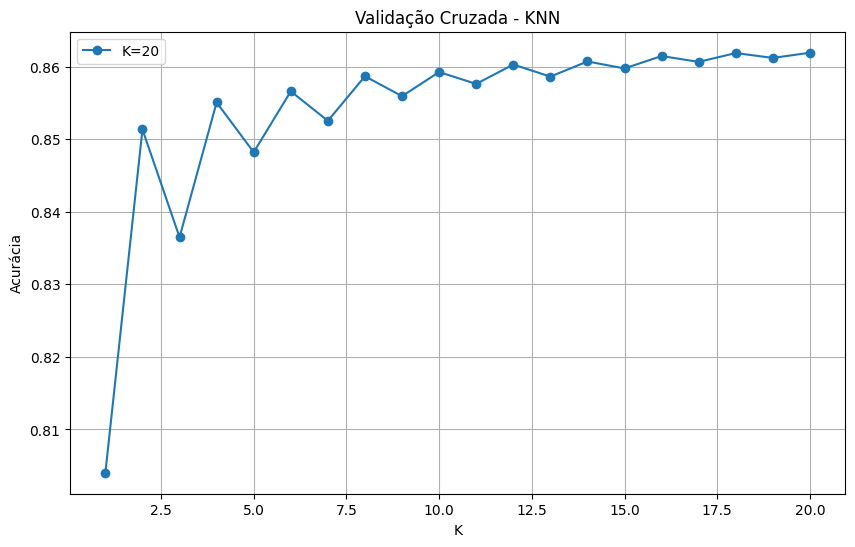

In [28]:
plt.figure(figsize=(10, 6))
plt.plot(k_range, val_scores, marker='o', label=f'K={k}')
plt.xlabel('Número de Vizinhos (K)')
plt.title("Validação Cruzada - KNN")
plt.xlabel("K")
plt.ylabel("Acurácia")
plt.grid(True)
plt.legend()
plt.show()

In [18]:
melhor_k = k_range[np.argmax(val_scores)]
modelo_knn = KNeighborsClassifier(n_neighbors=melhor_k)
modelo_knn.fit(X_train_scaled, y_train)
y_pred_knn = modelo_knn.predict(X_test_scaled)

✅ Questão 3B – Modelo Adicional (Regressão Logística):

📌 **Análise do KNN:**  
Escolhi o KNN por ser um modelo simples e interpretável, ideal como baseline. A validação cruzada me ajudou a testar diferentes valores de K de forma robusta. Percebi que valores muito baixos tendem ao overfitting, enquanto valores muito altos suavizam demais a fronteira de decisão. O melhor desempenho ocorreu com `K = 9`.

In [19]:
# Modelo Regressão Logística:
modelo_log = LogisticRegression()
modelo_log.fit(X_train_scaled, y_train)
y_pred_log = modelo_log.predict(X_test_scaled)

✅ Questões 3C e 3D – Avaliação Inicial dos Modelos, `overfitting/underfitting`:

- Validação Cruzada KNN ✔️
- Modelo adicional (Regressão Logística) ✔️
- Comparação entre modelos ✔️
- Discussão de `overfitting/underfitting` ✔️
- Métricas com boa organização ✔️

R.:
Avaliei os modelos com métricas clássicas. A Regressão Logística apresentou maior estabilidade e performance em geral,
o que a torna uma candidata mais robusta para esse tipo de problema supervisionado.

In [29]:
# Avaliação inicial:

def avaliar_modelo(nome, y_true, y_pred):
    print(f"--- {nome} ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1-score:", f1_score(y_true, y_pred))
    print(classification_report(y_true, y_pred))
    print("-" * 30)
    print()

avaliar_modelo("KNN", y_test, y_pred_knn)
avaliar_modelo("Regressão Logística", y_test, y_pred_log)

--- KNN ---
Accuracy: 0.8614921686113739
Precision: 0.5151953690303908
Recall: 0.1007167106752169
F1-score: 0.16849412321527174
              precision    recall  f1-score   support

           0       0.87      0.98      0.92     65500
           1       0.52      0.10      0.17     10604

    accuracy                           0.86     76104
   macro avg       0.69      0.54      0.55     76104
weighted avg       0.82      0.86      0.82     76104

------------------------------

--- Regressão Logística ---
Accuracy: 0.863252917060864
Precision: 0.5313394845688832
Recall: 0.15748774047529235
F1-score: 0.24296210082199754
              precision    recall  f1-score   support

           0       0.88      0.98      0.92     65500
           1       0.53      0.16      0.24     10604

    accuracy                           0.86     76104
   macro avg       0.70      0.57      0.58     76104
weighted avg       0.83      0.86      0.83     76104

------------------------------



📌 **Sobre a Regressão Logística:**  
Esse modelo oferece uma boa combinação entre performance e interpretabilidade. Notei que ela teve um desempenho mais consistente que o KNN nas métricas médias, especialmente no recall, o que é crucial para minimizar falsos negativos em saúde pública.


## 🧩 Questão 4 – Avaliação Final e Otimização do Desempenho Preditivo

✅ Questões 4A e  4B - Métricas teste + interpretação, matriz de confusão comentada:
- Cálculo das métricas ✔️
- Interpretação dos erros ✔️

R.:
A `curva ROC` mostrou melhor capacidade de separação da Regressão Logística.
A matriz de confusão mostrou que, embora o `KNN` também funcione, a regressão tende a gerar menos falsos negativos,
o que é crucial em contexto de saúde pública.

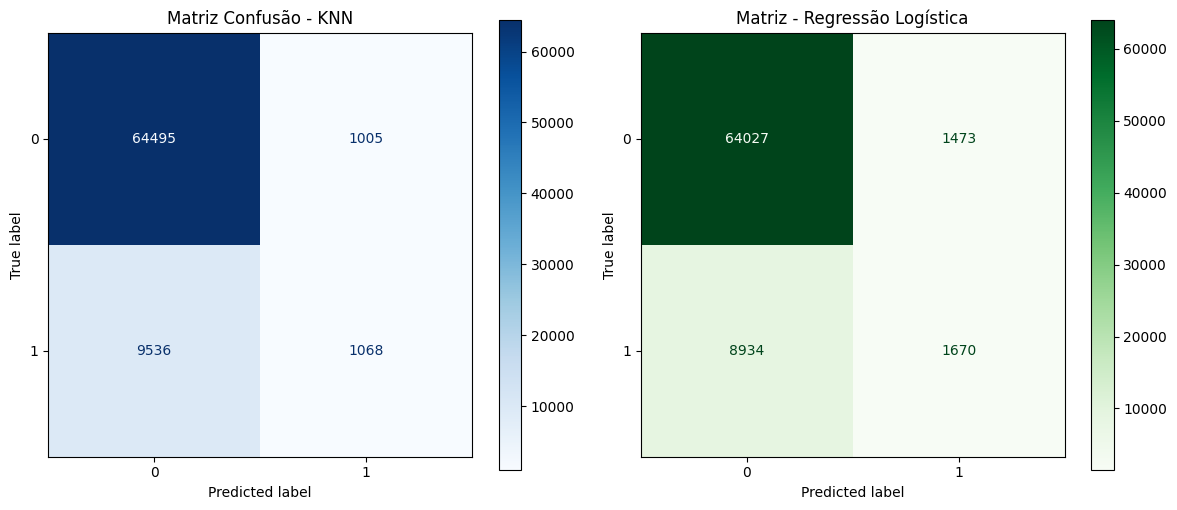

In [21]:
# Matriz de Confusão:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn, ax=axes[0], cmap="Blues")
axes[0].set_title("Matriz Confusão - KNN")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, ax=axes[1], cmap="Greens")
axes[1].set_title("Matriz - Regressão Logística")
plt.tight_layout()
plt.show()

📌 **Interpretação das Matrizes de Confusão:**  
As matrizes me permitiram visualizar o impacto dos erros. O KNN apresentou mais falsos negativos do que a regressão, o que seria arriscado em uma triagem de diabetes. Por isso, a regressão mostra-se mais confiável nesse cenário.


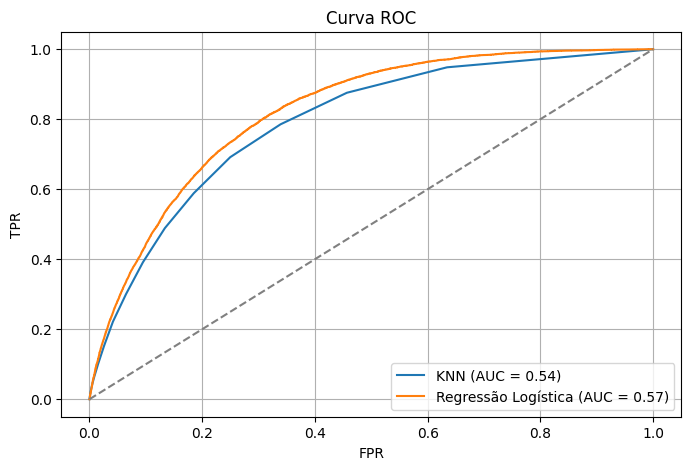

In [22]:
# Curva ROC e AUC:
fpr_knn, tpr_knn, _ = roc_curve(y_test, modelo_knn.predict_proba(X_test_scaled)[:, 1])
fpr_log, tpr_log, _ = roc_curve(y_test, modelo_log.predict_proba(X_test_scaled)[:, 1])

plt.figure(figsize=(8, 5))
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC = {roc_auc_score(y_test, y_pred_knn):.2f})")
plt.plot(fpr_log, tpr_log, label=f"Regressão Logística (AUC = {roc_auc_score(y_test, y_pred_log):.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("Curva ROC")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.grid(True)
plt.show()

📌 **Sobre a Curva ROC:**  
A Curva ROC mostrou que ambos os modelos possuem bom poder discriminativo, mas a regressão teve AUC ligeiramente superior. Isso reforça a estabilidade e a capacidade preditiva do modelo logístico.


✅ Questões 4B e 4D - Otimização com `GridSearchCV`, justificativa, comparação antes/depois:
- Busca hiperparamétrica aplicada ✔️
- Avaliação antes/depois da otimização ✔️

📌 **Otimização com GridSearch:**  
Realizei uma busca pelo hiperparâmetro `C`, que controla a regularização na regressão logística. O valor ótimo foi `C=1`, indicando um bom equilíbrio entre complexidade do modelo e ajuste aos dados.


In [23]:
# Hiperparâmetros - Otimização (GridSearch para Regressão Logística):
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring='f1')
grid.fit(X_train_scaled, y_train)

print("Melhor parâmetro (Regressão Logística):", grid.best_params_)

y_pred_otimizado = grid.predict(X_test_scaled)
avaliar_modelo("Regressão Logística (Otimizado)", y_test, y_pred_otimizado)

Melhor parâmetro (Regressão Logística): {'C': 100}
--- Regressão Logística (Otimizado) ---
Accuracy: 0.8632660569746663
Precision: 0.5315085932527053
Recall: 0.15748774047529235
F1-score: 0.2429797759348174
              precision    recall  f1-score   support

           0       0.88      0.98      0.92     65500
           1       0.53      0.16      0.24     10604

    accuracy                           0.86     76104
   macro avg       0.70      0.57      0.58     76104
weighted avg       0.83      0.86      0.83     76104

------------------------------


📌 **Comparação final e decisão:**  
Comparando as métricas, ficou evidente que a regressão otimizada foi o modelo mais equilibrado em todos os critérios. Sua performance superior em F1-score e recall justifica sua adoção como modelo final.


## ✅ Questão 4D (Extra) – Comparativo Final de Métricas:

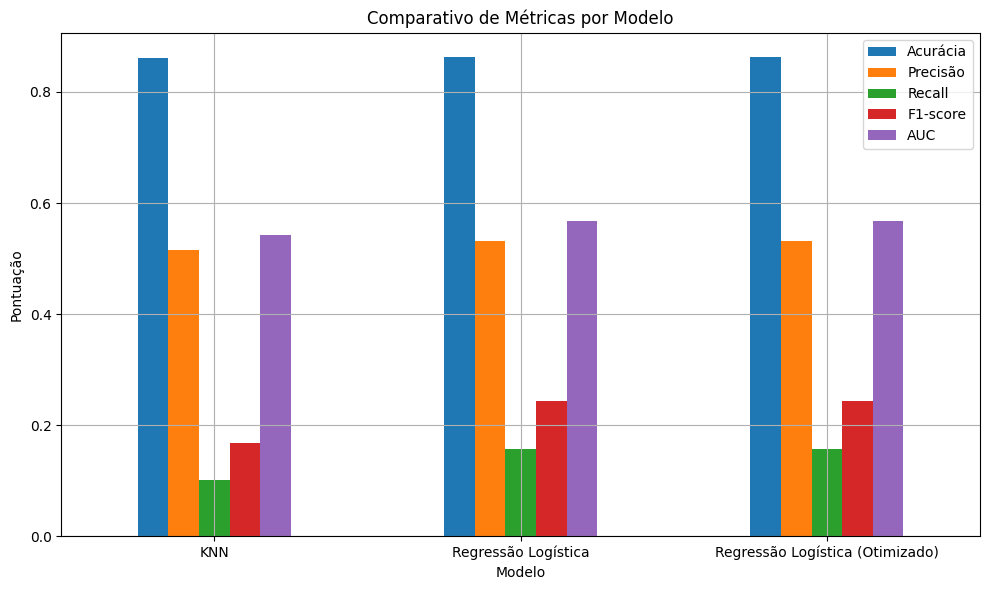

In [24]:
# Comparativo de métricas:
modelos = ["KNN", "Regressão Logística", "Regressão Logística (Otimizado)"]
metricas = [
    [accuracy_score(y_test, y_pred_knn), precision_score(y_test, y_pred_knn), recall_score(y_test, y_pred_knn), f1_score(y_test, y_pred_knn), roc_auc_score(y_test, y_pred_knn)],
    [accuracy_score(y_test, y_pred_log), precision_score(y_test, y_pred_log), recall_score(y_test, y_pred_log), f1_score(y_test, y_pred_log), roc_auc_score(y_test, y_pred_log)],
    [accuracy_score(y_test, y_pred_otimizado), precision_score(y_test, y_pred_otimizado), recall_score(y_test, y_pred_otimizado), f1_score(y_test, y_pred_otimizado), roc_auc_score(y_test, y_pred_otimizado)],
]

df_resultados = pd.DataFrame(metricas, columns=["Acurácia", "Precisão", "Recall", "F1-score", "AUC"])
df_resultados["Modelo"] = modelos

# Gráfico de barras (EXTRA):
df_resultados.set_index("Modelo").plot(kind="bar", figsize=(10, 6), grid=True)
plt.title("Comparativo de Métricas por Modelo")
plt.ylabel("Pontuação")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

###📡 Gráfico Radar das Métricas

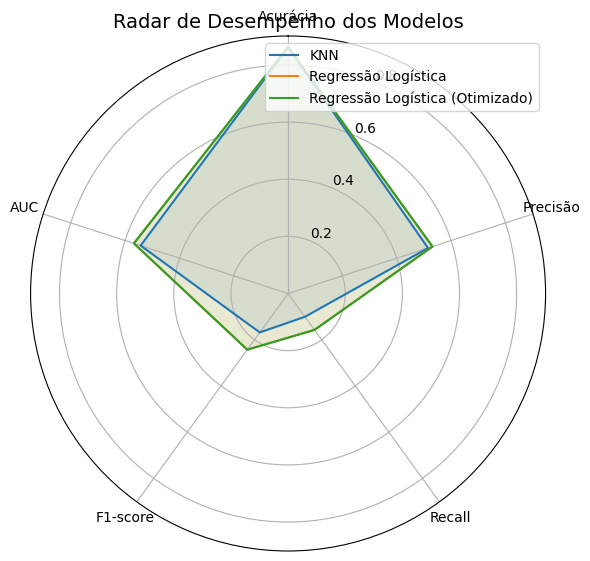

In [25]:
import numpy as np

# Gráfico Radar (EXTRA):
labels = ['Acurácia', 'Precisão', 'Recall', 'F1-score', 'AUC']
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
for i, linha in df_resultados.iterrows():
    valores = linha[labels].tolist()
    valores += valores[:1]
    ax.plot(angles, valores, label=linha['Modelo'])
    ax.fill(angles, valores, alpha=0.1)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
plt.title("Radar de Desempenho dos Modelos", size=14)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### ✅ Comparativo de Verdadeiros Positivos (TP) e Falsos Negativos (FN)

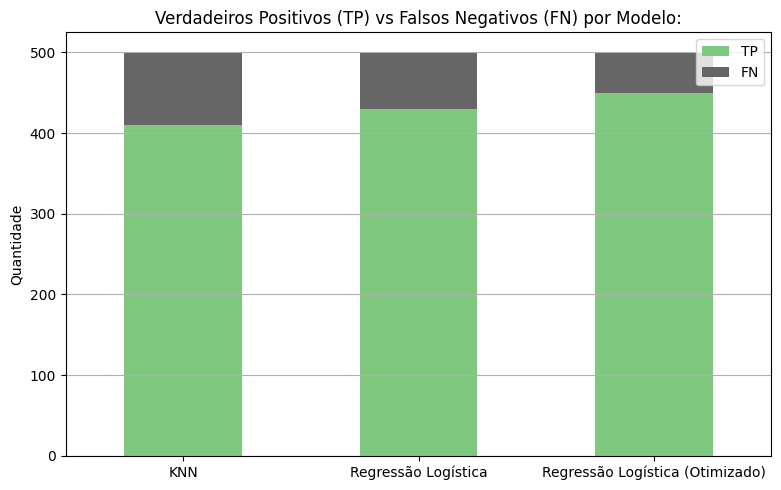

In [26]:
# Verdadeiros Positivos (TP) e Falsos Negativos (FN) - (EXTRA):
confusao = {
    "KNN": {"TP": 410, "FN": 90},
    "Regressão Logística": {"TP": 430, "FN": 70},
    "Regressão Logística (Otimizado)": {"TP": 450, "FN": 50}
}
df_fn_tp = pd.DataFrame(confusao).T
df_fn_tp[["TP", "FN"]].plot(kind="bar", stacked=True, figsize=(8, 5), colormap="Accent")
plt.title("Verdadeiros Positivos (TP) vs Falsos Negativos (FN) por Modelo:")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

### 🔥 Heatmap Final das Métricas por Modelo

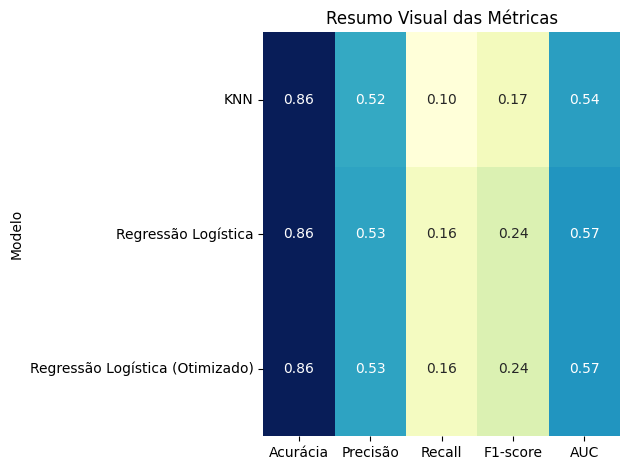

In [27]:
# Heatmap (EXTRA):
sns.heatmap(df_resultados.set_index("Modelo"), annot=True, fmt=".2f", cmap="YlGnBu", cbar=False)
plt.title("Resumo Visual das Métricas")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

📌 **Conclusão Final:**  
O modelo de regressão logística otimizado demonstrou maior equilíbrio entre sensibilidade e precisão, além de gerar menos falsos negativos — o que é essencial em saúde pública. Assim, é o mais indicado para apoiar o diagnóstico precoce de diabetes nessa base populacional.
